## Data exploring

In [1]:
from tdc.multi_pred import DDI
data = DDI(name='DrugBank')
df = data.get_data()
print(df.head())
print(df.shape)

Found local copy...
Loading...
Done!


  Drug1_ID                                       Drug1 Drug2_ID  \
0  DB04571         CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1  DB00460   
1  DB00855                             NCC(=O)CCC(O)=O  DB00460   
2  DB09536                                    O=[Ti]=O  DB00460   
3  DB01600       CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1  DB00460   
4  DB09000  CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N  DB00460   

                                               Drug2  Y  
0  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...  1  
1  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...  1  
2  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...  1  
3  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...  1  
4  COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...  1  
(191808, 5)


In [2]:
print(df.shape)
                  # how many drug pairs? 
print(df['Y'].value_counts())      # class distribution 
print(df.isnull().sum())           # missing values 
df['Drug1'].sample(5).tolist()     # inspect some SMILES strings

(191808, 5)
Y
49    60751
47    34360
73    23779
75     9470
60     8397
      ...  
28       11
1        11
52       10
26        7
42        6
Name: count, Length: 86, dtype: int64
Drug1_ID    0
Drug1       0
Drug2_ID    0
Drug2       0
Y           0
dtype: int64


['CCC1(CCC(C)C)C(=O)NC(=O)NC1=O',
 'NNCCC1=CC=CC=C1',
 'CCC1(C(=O)NCNC1=O)C1=CC=CC=C1',
 'N1C2=CC=CC=C2N=C1C1=CSC=N1',
 'CNCCCC1C2=CC=CC=C2C=CC2=CC=CC=C12']

In [3]:
print(df.head)  #getting data set info

<bound method NDFrame.head of        Drug1_ID                                              Drug1 Drug2_ID  \
0       DB04571                CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1  DB00460   
1       DB00855                                    NCC(=O)CCC(O)=O  DB00460   
2       DB09536                                           O=[Ti]=O  DB00460   
3       DB01600              CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1  DB00460   
4       DB09000         CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N  DB00460   
...         ...                                                ...      ...   
191803  DB00437                                 OC1=NC=NC2=C1C=NN2  DB00492   
191804  DB00437                                 OC1=NC=NC2=C1C=NN2  DB09477   
191805  DB00437                                 OC1=NC=NC2=C1C=NN2  DB00790   
191806  DB00415  [H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...  DB00437   
191807  DB00437                                 OC1=NC=NC2=C1C=NN2  DB00691   

                     

In [4]:
from tdc.utils import get_label_map #getting info on interaction type. 

label_map = get_label_map(name='DrugBank', task='DDI')
print(label_map)

{1: '#Drug1 may increase the photosensitizing activities of #Drug2.', 2: '#Drug1 may increase the anticholinergic activities of #Drug2.', 3: 'The bioavailability of #Drug2 can be decreased when combined with #Drug1.', 4: 'The metabolism of #Drug2 can be increased when combined with #Drug1.', 5: '#Drug1 may decrease the vasoconstricting activities of #Drug2.', 6: '#Drug1 may increase the anticoagulant activities of #Drug2.', 7: '#Drug1 may increase the ototoxic activities of #Drug2.', 8: 'The therapeutic efficacy of #Drug2 can be increased when used in combination with #Drug1.', 9: '#Drug1 may increase the hypoglycemic activities of #Drug2.', 10: '#Drug1 may increase the antihypertensive activities of #Drug2.', 11: 'The serum concentration of the active metabolites of #Drug2 can be reduced when #Drug2 is used in combination with #Drug1 resulting in a loss in efficacy.', 12: '#Drug1 may decrease the anticoagulant activities of #Drug2.', 13: 'The absorption of #Drug2 can be decreased when

## Class Thresholds

In [6]:
class_counts = df['Y'].value_counts() #Getting the minimum threshold for a class, to account for classes to small to train/test

for threshold in [20, 30, 50, 100]:
    n_kept = (class_counts >= threshold).sum()
    n_merged = (class_counts < threshold).sum()
    rows_in_other = class_counts[class_counts < threshold].sum()
    print(f"threshold={threshold}: {n_kept} classes kept, {n_merged} merged into 'Other' "
          f"({rows_in_other} rows, {rows_in_other/len(df):.1%} of data)")

threshold=20: 76 classes kept, 10 merged into 'Other' (108 rows, 0.1% of data)
threshold=30: 70 classes kept, 16 merged into 'Other' (263 rows, 0.1% of data)
threshold=50: 63 classes kept, 23 merged into 'Other' (516 rows, 0.3% of data)
threshold=100: 53 classes kept, 33 merged into 'Other' (1275 rows, 0.7% of data)


In [7]:
#Deciding on a threshold of 100. Still produces 53 classes, at only the cost of .7% of data lost to 'other'. 
threshold = 100
class_counts = df['Y'].value_counts()
rare_labels = class_counts[class_counts < threshold].index

df['Y_grouped'] = df['Y'].apply(lambda y: 'Other' if y in rare_labels else y)

print(df['Y_grouped'].value_counts())
print(f"\nTotal classes: {df['Y_grouped'].nunique()}")

Y_grouped
49       60751
47       34360
73       23779
75        9470
60        8397
70        7786
20        6140
16        5413
4         5011
6         3160
37        3089
9         2109
72        1825
54        1277
Other     1275
83        1204
58        1043
32        1011
27         936
67         930
64         803
25         716
71         673
57         664
10         629
30         616
76         558
77         538
3          518
61         498
33         442
21         428
74         422
85         372
14         361
82         355
53         336
29         324
2          323
11         312
34         312
5          309
40         300
69         280
68         278
8          244
12         238
15         202
24         180
39         148
66         128
55         118
19         109
81         108
Name: count, dtype: int64

Total classes: 54


## Sanity Checking the Categorizing

In [8]:
#Raw count integrity
assert df['Y_grouped'].value_counts().sum() == len(df)
assert df['Y_grouped'].isnull().sum() == 0
print("Row count check passed" if df['Y_grouped'].value_counts().sum() == len(df) else "MISMATCH")

Row count check passed


In [9]:
#Class count matches
print(f"Total classes: {df['Y_grouped'].nunique()}")  # should be 54
print(f"Min class size: {df['Y_grouped'].value_counts().min()}")  # should be ~100+, except possibly Other

Total classes: 54
Min class size: 108


In [10]:
#Merge Logic
from tdc.utils import get_label_map
label_map = get_label_map(name='DrugBank', task='DDI')

rare_labels = class_counts[class_counts < 100].index
print("Labels merged into 'Other':")
for label_id in rare_labels:
    print(f"  {label_id}: {label_map[label_id]} ({class_counts[label_id]} samples)")

Labels merged into 'Other':
  36: #Drug1 may increase the antipsychotic activities of #Drug2. (94 samples)
  22: #Drug1 may increase the adverse neuromuscular activities of #Drug2. (94 samples)
  17: #Drug1 may decrease the neuromuscular blocking activities of #Drug2. (83 samples)
  51: #Drug1 may increase the hypercalcemic activities of #Drug2. (83 samples)
  18: #Drug1 can cause an increase in the absorption of #Drug2 resulting in an increased serum concentration and potentially a worsening of adverse effects. (82 samples)
  48: #Drug1 may increase the myopathic rhabdomyolysis activities of #Drug2. (69 samples)
  35: #Drug1 may increase the neurotoxic activities of #Drug2. (69 samples)
  84: #Drug1 may increase the vasopressor activities of #Drug2. (65 samples)
  80: #Drug1 may increase the hepatotoxic activities of #Drug2. (64 samples)
  23: #Drug1 may increase the stimulatory activities of #Drug2. (56 samples)
  13: The absorption of #Drug2 can be decreased when combined with #Drug

In [11]:
#Large class check
assert (df.loc[df['Y'] == 49, 'Y_grouped'] == 49).all()
print("Largest class unchanged: OK")

Largest class unchanged: OK


## Plot demonstrating the merged class effect

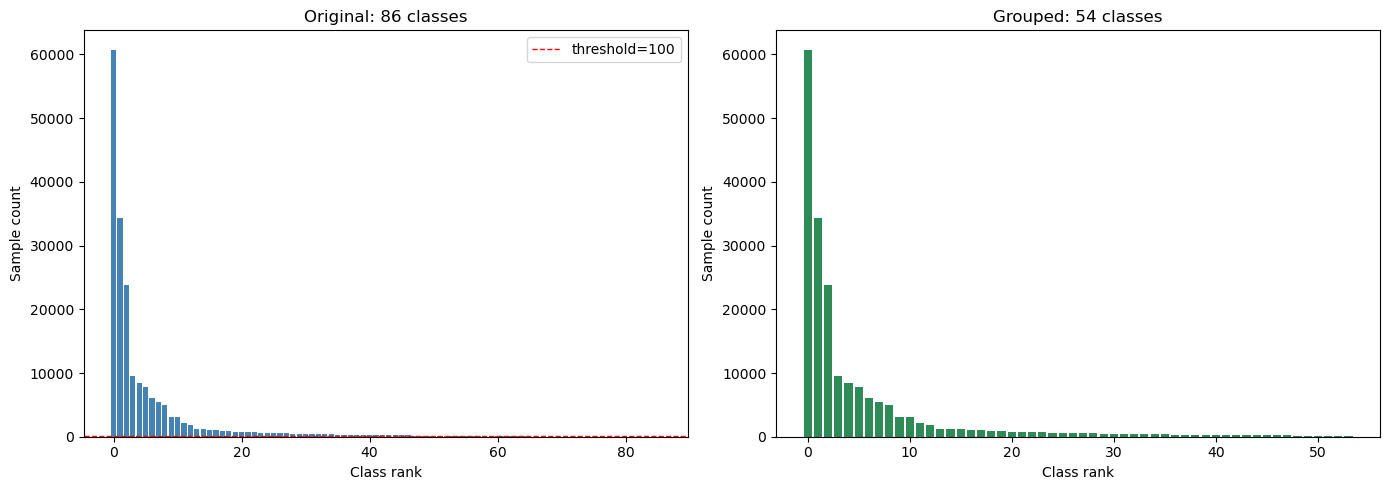

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: original 86 classes, sorted descending
before = df['Y'].value_counts().sort_values(ascending=False)
axes[0].bar(range(len(before)), before.values, color='steelblue')
axes[0].set_title(f'Original: {len(before)} classes')
axes[0].set_xlabel('Class rank')
axes[0].set_ylabel('Sample count')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=1, label='threshold=100')
axes[0].legend()

# After: grouped classes, sorted descending
after = df['Y_grouped'].value_counts().sort_values(ascending=False)
axes[1].bar(range(len(after)), after.values, color='seagreen')
axes[1].set_title(f'Grouped: {len(after)} classes')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Sample count')

plt.tight_layout()
plt.savefig('class_distribution_before_after.png', dpi=150)
plt.show()

## Some SMILES

In [13]:
import numpy as np
import sys
sys.path.append('..')  # so notebooks/ can see src/
from src.features import smiles_to_fp

fp1 = np.vstack(df['Drug1'].apply(smiles_to_fp))
fp2 = np.vstack(df['Drug2'].apply(smiles_to_fp))
X = np.concatenate([fp1, fp2], axis=1)  # shape: (191808, 4096)
y = df['Y_grouped'].values

[17:43:27] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[17:43:27] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:43:42] Explicit valence for atom # 0 N, 4, is greater

In [14]:
#Check for memory purposes -NumPy defaulted whole dataset to float b/c of those few invalid SMILES
print(X.dtype, X.nbytes / 1e9, "GB")

uint8 0.785645568 GB


In [15]:
# Saving Progress

np.save('../data/X_fingerprints.npy', X)
np.save('../data/y_labels.npy', y)
print("Saved:", X.shape, y.shape)

Saved: (191808, 4096) (191808,)


In [ ]:
# Reloading Save
import numpy as np

X = np.load('../data/X_fingerprints.npy')
y = np.load('../data/y_labels.npy', allow_pickle=True)

print("Loaded:", X.shape, y.shape)

In [16]:
#Checking for more invalid drugs
n_invalid_drug1 = (fp1.sum(axis=1) == 0).sum()
n_invalid_drug2 = (fp2.sum(axis=1) == 0).sum()
print(f"Invalid SMILES — Drug1: {n_invalid_drug1} ({n_invalid_drug1/len(df):.2%})")
print(f"Invalid SMILES — Drug2: {n_invalid_drug2} ({n_invalid_drug2/len(df):.2%})")

Invalid SMILES — Drug1: 112 (0.06%)
Invalid SMILES — Drug2: 59 (0.03%)


## Training and Splitting

In [ ]:
#  Drop rows with invalid SMILES (0.06% + 0.03% — small enough to drop cleanly) 
valid_mask = (fp1.sum(axis=1) != 0) & (fp2.sum(axis=1) != 0)
print(f"Dropping {(~valid_mask).sum()} rows ({(~valid_mask).sum()/len(df):.2%})")

X_valid = X[valid_mask]
y_valid = y[valid_mask].astype(str)   # avoids int/str sort crash in sklearn

#  Encode labels (XGBoost needs 0..N-1 integers, not raw class IDs/strings) 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_valid)
print(f"Classes: {len(le.classes_)}")

Dropping 171 rows (0.09%)
Classes: 54


In [ ]:
#  Stratified train/val/test split, using the encoded 54-class labels 
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_valid, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(134145, 4096) (28746, 4096) (28746, 4096)


## Phase 3 - Random Forest, XGBoost, Metrics

In [19]:
#  Random Forest baseline, with class_weight='balanced' instead of default 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
print(classification_report(y_val, y_pred_rf, target_names=le.classes_, zero_division=0))
print('Macro F1:', f1_score(y_val, y_pred_rf, average='macro'))

              precision    recall  f1-score   support

          10       0.79      0.97      0.87        95
          11       0.72      0.49      0.58        47
          12       0.84      0.77      0.81        35
          14       0.98      0.98      0.98        54
          15       0.67      0.97      0.79        30
          16       0.86      0.89      0.88       812
          19       1.00      0.81      0.90        16
           2       0.80      0.67      0.73        48
          20       0.80      0.80      0.80       921
          21       0.98      0.89      0.93        64
          24       1.00      1.00      1.00        27
          25       0.95      0.85      0.90       108
          27       0.98      0.97      0.98       141
          29       0.83      0.83      0.83        48
           3       1.00      1.00      1.00        77
          30       0.82      0.81      0.81        93
          32       0.80      0.99      0.89       152
          33       0.67    

In [20]:
# XGBoost, multiclass version, with sample weighting for the imbalance
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-mlogloss:3.47715
[50]	validation_0-mlogloss:1.18300
[100]	validation_0-mlogloss:0.84022
[150]	validation_0-mlogloss:0.70773
[200]	validation_0-mlogloss:0.62612
[250]	validation_0-mlogloss:0.56770
[299]	validation_0-mlogloss:0.52358


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [21]:
# --- Evaluate on the held-out test set ---
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
print('Macro F1:', f1_score(y_test, y_pred, average='macro'))
print('Micro F1:', f1_score(y_test, y_pred, average='micro'))

              precision    recall  f1-score   support

          10       0.82      1.00      0.90        94
          11       0.42      0.79      0.54        47
          12       0.78      1.00      0.88        36
          14       0.95      1.00      0.97        54
          15       0.67      0.97      0.79        29
          16       0.87      0.98      0.92       812
          19       0.89      0.94      0.91        17
           2       0.65      0.94      0.77        49
          20       0.78      0.95      0.85       921
          21       0.90      0.97      0.93        64
          24       0.93      1.00      0.96        27
          25       0.89      1.00      0.94       107
          27       0.95      0.99      0.97       140
          29       0.71      0.96      0.82        49
           3       0.96      1.00      0.98        78
          30       0.66      0.96      0.78        92
          32       0.81      1.00      0.89       151
          33       0.47    

In [22]:
# Save model AND the label encoder (Phase 4/5 need it to map predictions
# back to readable interaction text 
import joblib
joblib.dump(model, '../models/ddi_xgb.joblib')
joblib.dump(le, '../models/label_encoder.joblib')
print('Saved.')

Saved.


## Confusion Matrices and Metrics

              precision    recall  f1-score   support

          10       0.82      1.00      0.90        94
          11       0.42      0.79      0.54        47
          12       0.78      1.00      0.88        36
          14       0.95      1.00      0.97        54
          15       0.67      0.97      0.79        29
          16       0.87      0.98      0.92       812
          19       0.89      0.94      0.91        17
           2       0.65      0.94      0.77        49
          20       0.78      0.95      0.85       921
          21       0.90      0.97      0.93        64
          24       0.93      1.00      0.96        27
          25       0.89      1.00      0.94       107
          27       0.95      0.99      0.97       140
          29       0.71      0.96      0.82        49
           3       0.96      1.00      0.98        78
          30       0.66      0.96      0.78        92
          32       0.81      1.00      0.89       151
          33       0.47    

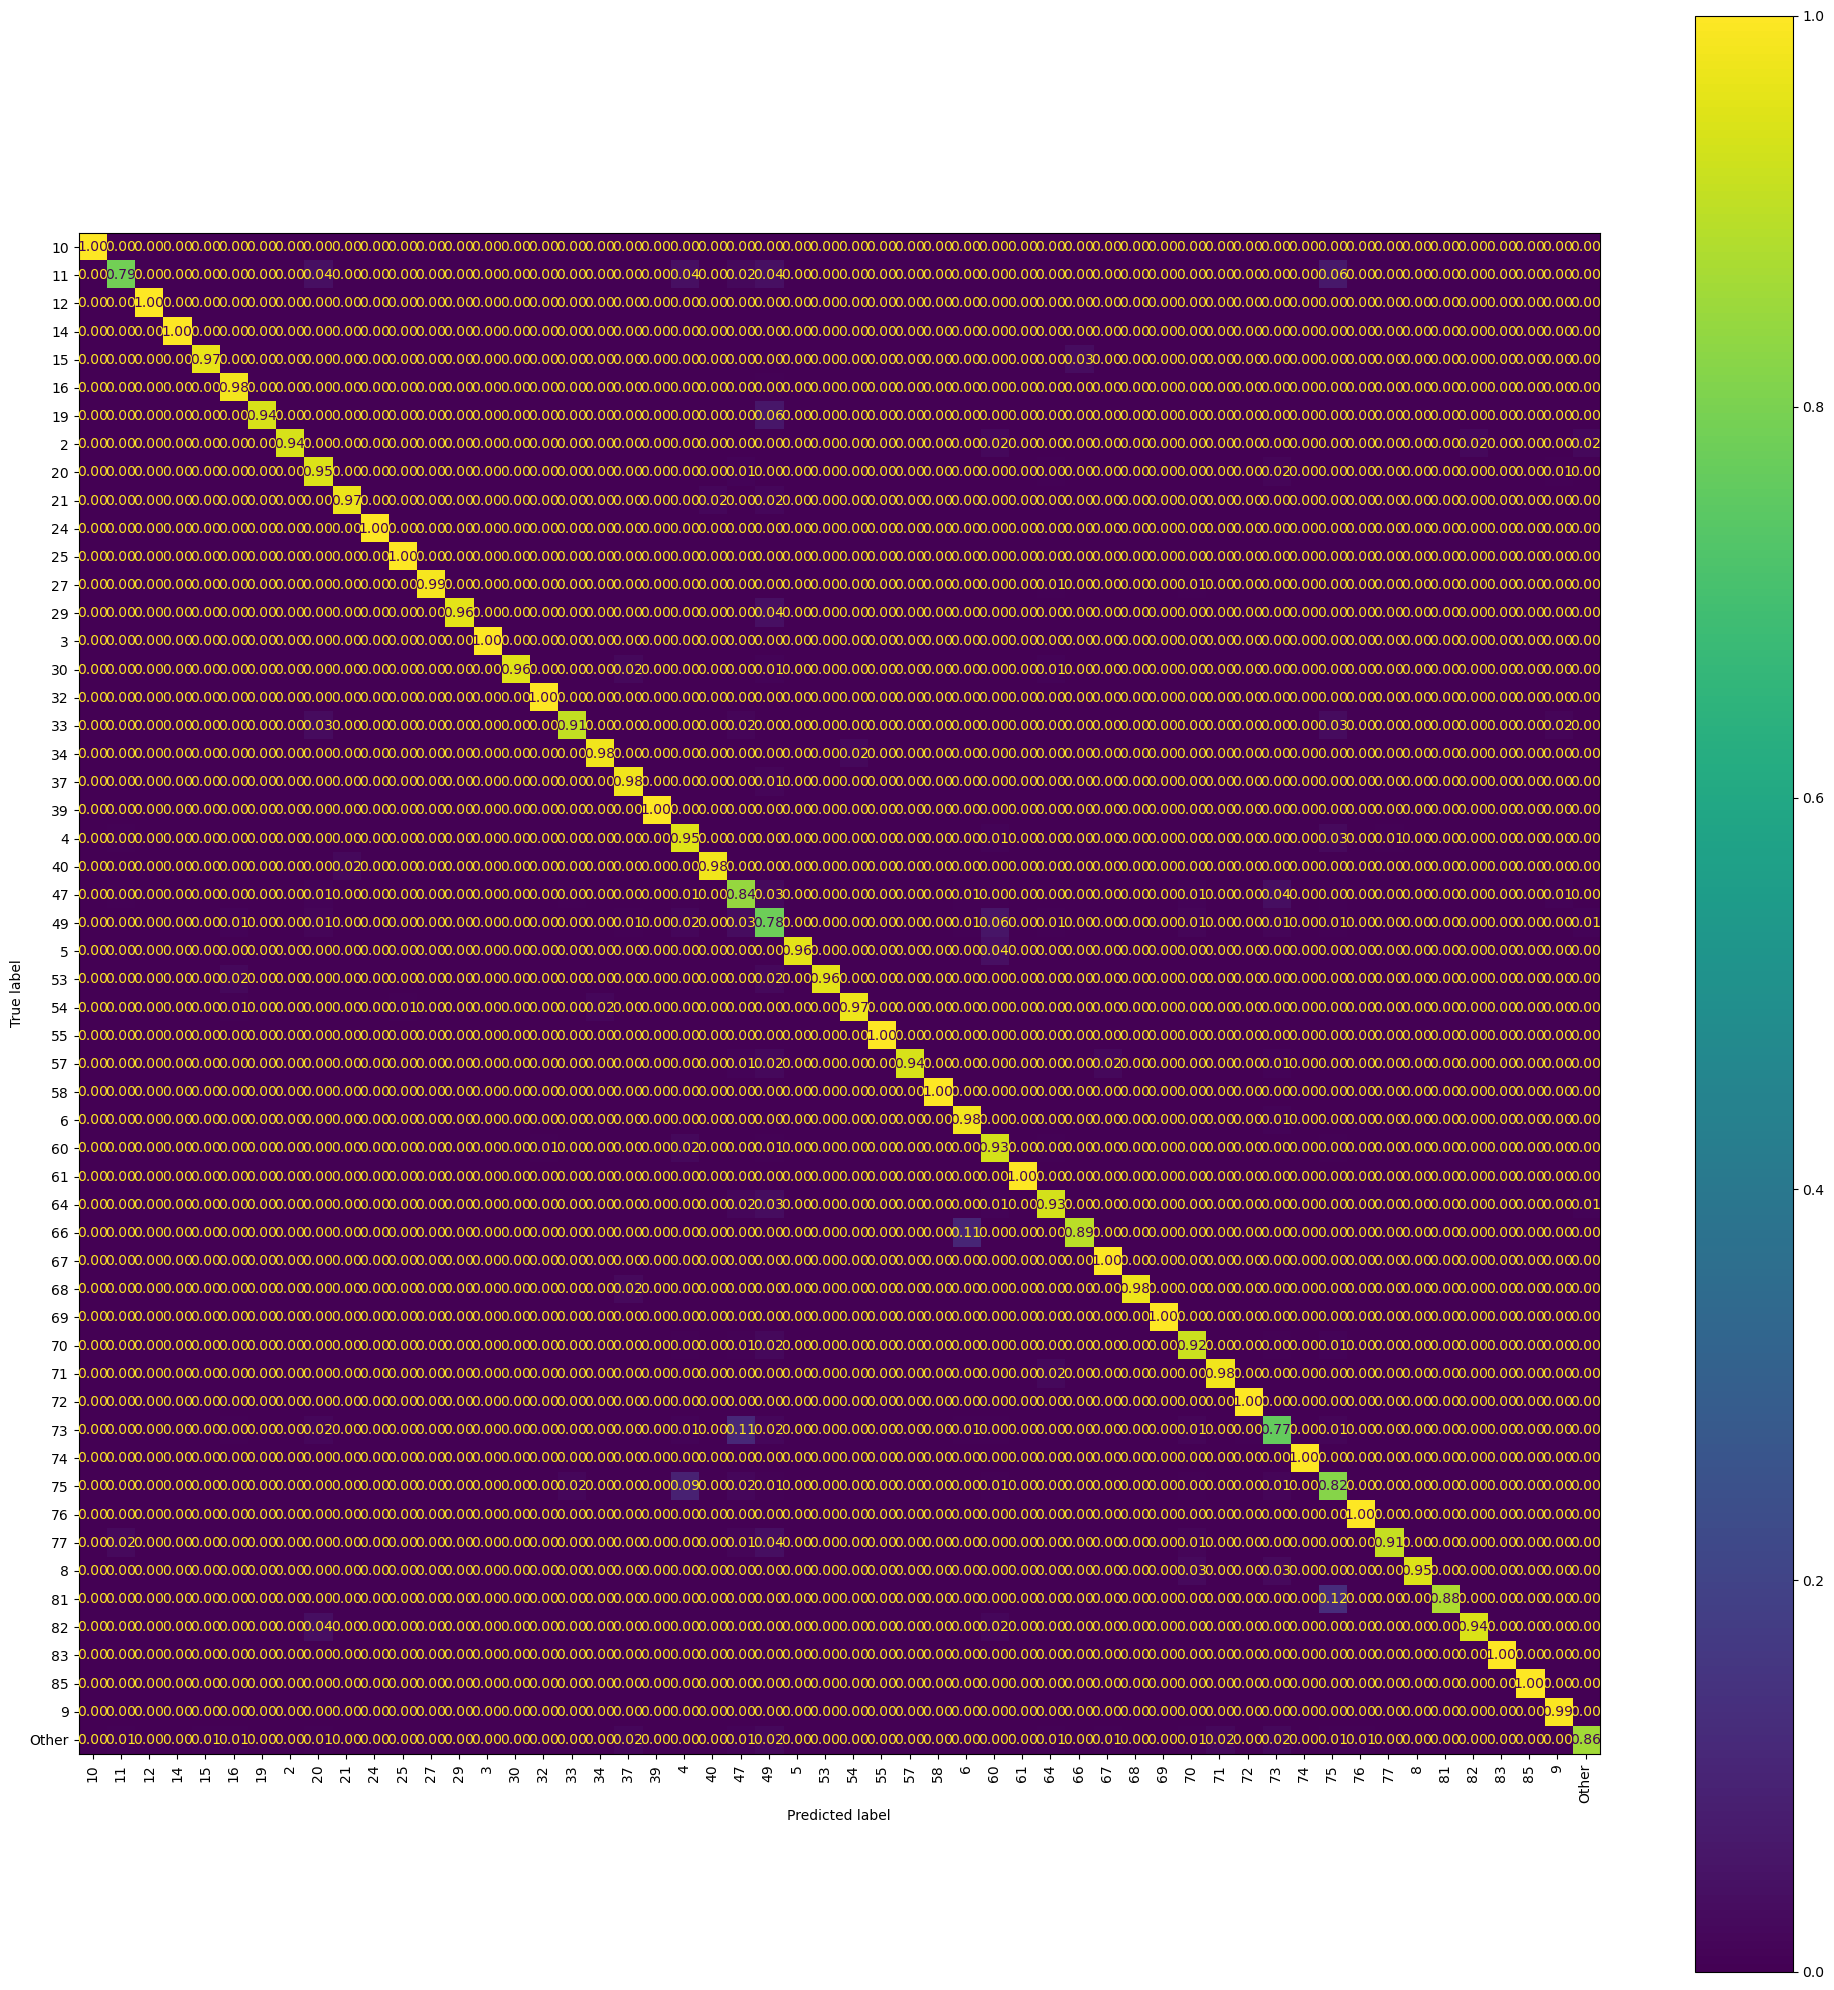

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

# Classification report with actual interaction-type names, not raw class IDs
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Headline metrics — macro-F1 treats every class equally regardless of size,
# which is the honest metric for a 54-class dataset this imbalanced.
# Micro-F1 is close to overall accuracy for context alongside it.
print('Macro F1:', f1_score(y_test, y_pred, average='macro'))
print('Micro F1:', f1_score(y_test, y_pred, average='micro'))

# Confusion matrix — normalized by row, so the biggest classes (60k+ samples)
# don't visually drown out everything else, and sized/rotated to stay legible
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, values_format='.2f', colorbar=True)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()

As can be seen, a 54 x 54 confusion matrix is terrible to behold. 

So we will recreate it for only the top 15 classes

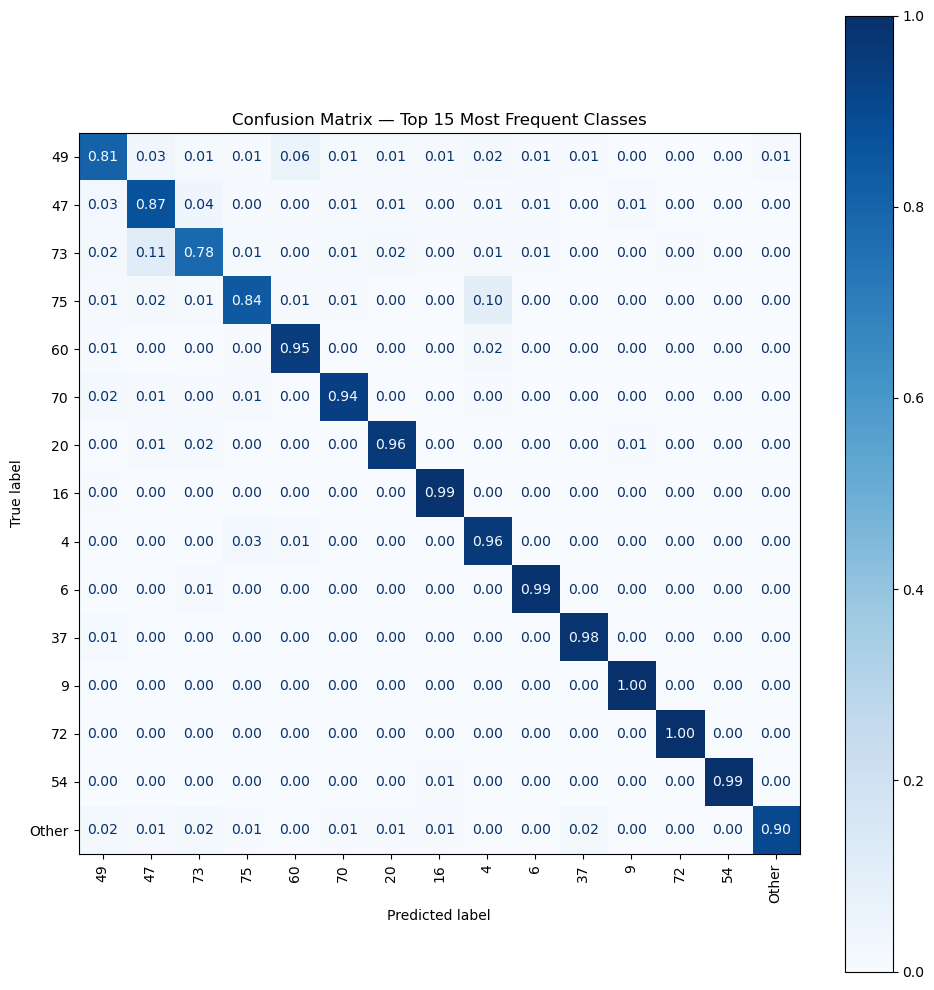

In [24]:
import numpy as np

# Find the top N most frequent classes in the test set
N = 15
top_classes_idx = np.argsort(-np.bincount(y_test, minlength=len(le.classes_)))[:N]
top_class_names = le.classes_[top_classes_idx]

# Build a mask: keep only test rows whose TRUE label is one of the top N
mask = np.isin(y_test, top_classes_idx)
y_test_top = y_test[mask]
y_pred_top = y_pred[mask]

# Confusion matrix restricted to those classes only
cm_top = confusion_matrix(y_test_top, y_pred_top, labels=top_classes_idx, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(cm_top, display_labels=top_class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format='.2f', colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — Top {N} Most Frequent Classes')
plt.tight_layout()
plt.savefig('../models/confusion_matrix_top15.png', dpi=150)
plt.show()

## What structure makes certain interactions happen?


In [ ]:
import xgboost as xgb

# Smoke test first — confirm this is fast before committing to the full 500 rows
dtest_small = xgb.DMatrix(X_test[:5])
contribs_small = model.get_booster().predict(dtest_small, pred_contribs=True)
print(contribs_small.shape)  # (5, 54, 4097) — last column is the base value

(5, 54, 4097)


In [26]:
sample_size = 500
dtest = xgb.DMatrix(X_test[:sample_size])
contribs = model.get_booster().predict(dtest, pred_contribs=True)  # (500, 54, 4097)
y_pred_sample = model.predict(X_test[:sample_size])

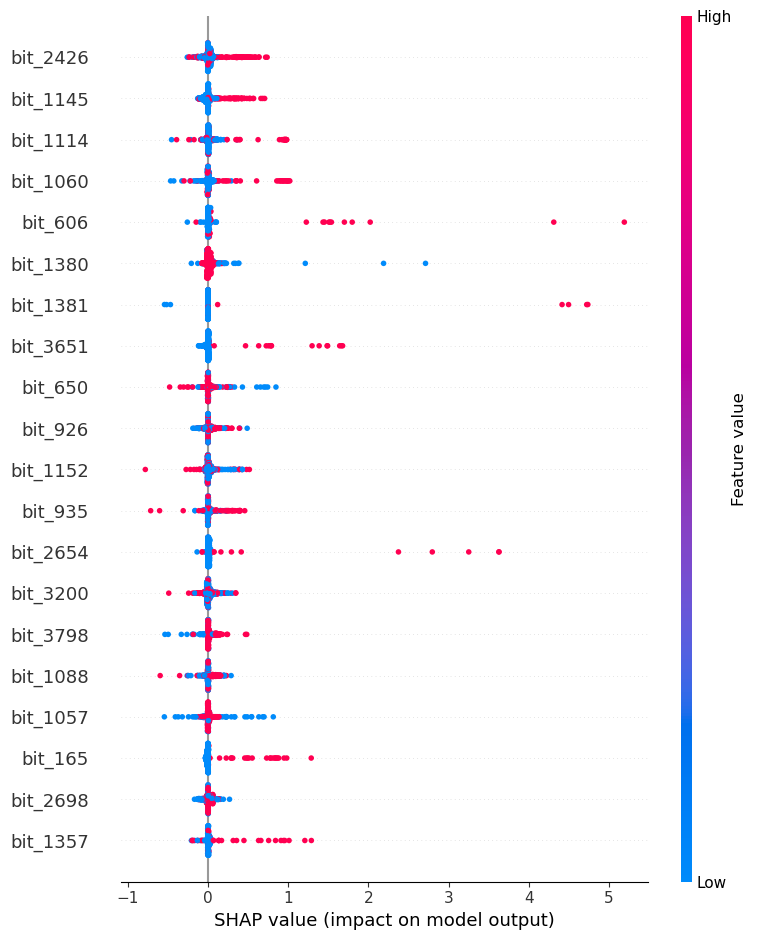

In [27]:
#This summary plot is restricted to each sample's predicted class, and does not consider ALL the interaction types.
#This is vital for speed, and to understand why the model assigned a specific interaction to a sample. 

import numpy as np
import matplotlib.pyplot as plt
import shap  # still used for its plotting utilities, just not its explainer

idx = np.arange(sample_size)
sample_contribs = contribs[idx, y_pred_sample, :-1]  # drop base-value column

shap.summary_plot(
    sample_contribs, X_test[:sample_size],
    feature_names=[f'bit_{i}' for i in range(X_test.shape[1])],
    show=False
)
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')

In [31]:
fp1_example = smiles_to_fp('CC(=O)Oc1ccccc1C(=O)O')  # aspirin
fp2_example = smiles_to_fp('CC(=O)Nc1ccc(O)cc1')       # acetaminophen, as an example

label, top_features = explain_prediction(fp1_example, fp2_example, model, le)
print(label)
print(top_features)

6
[(1468, 1.6124606132507324), (650, 0.22912290692329407), (1970, -0.2280394434928894), (1876, -0.17999333143234253), (1057, -0.14751140773296356), (2891, -0.13176700472831726), (1602, -0.12879224121570587), (3965, 0.12043873965740204), (2128, 0.10923208296298981), (3162, 0.08135154843330383)]


In [34]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

info = {}
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')  # aspirin
fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048, bitInfo=info)
print(info)

{389: ((12, 1),), 456: ((10, 1),), 650: ((2, 0), (11, 0)), 695: ((3, 0),), 807: ((1, 0), (10, 0), (12, 0)), 909: ((4, 2),), 1017: ((0, 1),), 1035: ((1, 1),), 1047: ((10, 2),), 1057: ((0, 0),), 1088: ((6, 1), (7, 1)), 1199: ((6, 2), (7, 2)), 1380: ((4, 0), (9, 0)), 1410: ((5, 2),), 1447: ((8, 2),), 1468: ((3, 2),), 1616: ((9, 2),), 1729: ((3, 1),), 1750: ((5, 1), (8, 1)), 1775: ((1, 2),), 1873: ((5, 0), (6, 0), (7, 0), (8, 0)), 1917: ((2, 1), (11, 1)), 1970: ((4, 1),), 1991: ((9, 1),)}


In [35]:
from src.predict import predict_from_smiles

label, top_features = predict_from_smiles(
    'CC(=O)Oc1ccccc1C(=O)O',  # aspirin
    'CC(=O)Nc1ccc(O)cc1'       # acetaminophen
)
print(label)
print(top_features)

6
[(1468, 1.6124606132507324), (650, 0.22912290692329407), (1970, -0.2280394434928894), (1876, -0.17999333143234253), (1057, -0.14751140773296356), (2891, -0.13176700472831726), (1602, -0.12879224121570587), (3965, 0.12043873965740204), (2128, 0.10923208296298981), (3162, 0.08135154843330383)]
